# ZipBench on LiveCodeBench (text modality)

This notebook runs the full ZipBench compression pipeline on **LiveCodeBench** (1055 items), a text-modality benchmark with an explicit per-item correctness field. We start from raw answer records of **6 training models** and **10 held-out test models**, synthesize 6 additional training models by ensemble voting, fit a multidimensional 2PL IRT model, and compress the benchmark to weighted anchor subsets at ratios 0.5 and 0.75.

Record layout: `data/LiveCodeBench/{train,testset}/<model>/LiveCodeBench.json`.

## 1. Inspect the raw records

Each record JSON holds the model's overall accuracy plus a per-item `details` map with boolean `is_correct` flags.

In [1]:
import json, os

TRAIN = "../data/LiveCodeBench/train"
TEST = "../data/LiveCodeBench/testset"

model = sorted(os.listdir(TRAIN))[0]
rec = json.load(open(f"{TRAIN}/{model}/LiveCodeBench.json"))
print(f"model: {model}")
print(f"top-level keys: {list(rec.keys())}")
print(f"accuracy: {rec['accuracy']:.2f}  |  items: {len(rec['details'])}")
print("first detail entry:", json.dumps(dict(list(rec['details'].items())[:1]), indent=2))

model: Qwen3-4B-Instruct-2507-8192
top-level keys: ['is_correct', 'accuracy', 'details']
accuracy: 48.25  |  items: 1055
first detail entry: {
  "0": {
    "is_correct": true,
    "source_metric": "pass@1",
    "source_file": "Scenario.codegeneration_1_0.6_eval.json"
  }
}


In [2]:
def list_models(root):
    for m in sorted(os.listdir(root)):
        r = json.load(open(f"{root}/{m}/LiveCodeBench.json"))
        print(f"  {m:45s} acc = {r['accuracy']:6.2f}  ({len(r['details'])} items)")

print("Train models (6 real):")
list_models(TRAIN)
print("\nHeld-out test models (10):")
list_models(TEST)

Train models (6 real):
  Qwen3-4B-Instruct-2507-8192                   acc =  48.25  (1055 items)
  Qwen3-VL-32B-Thinking-8192                    acc =  37.35  (1055 items)
  deepseek-v4-flash-16k                         acc =  56.02  (1055 items)
  deepseek-v4-pro                               acc =  67.87  (1055 items)
  gemini-3-5-flash                              acc =  90.62  (1055 items)
  qwen3-6-plus                                  acc =  79.81  (1055 items)

Held-out test models (10):
  Qwen3-30B-A3B-Thinking-2507                   acc =  74.12  (1055 items)
  Qwen3-30B-A3B-Thinking-2507-8192              acc =  51.94  (1055 items)
  Qwen3-32B                                     acc =  75.45  (1055 items)
  Qwen3-4B-Instruct-2507                        acc =  43.13  (1055 items)
  deepseek-v4-flash-65k                         acc =  82.65  (1055 items)
  gemini-3-flash                                acc =  52.42  (1055 items)
  gpt-5.4-high                                  a

## 2. Synthesize 6 training models

Ensemble voting over the 6 real records fills 6 uniform accuracy bins with new synthetic models (`--strict-bins` fails loudly if a bin cannot be filled).

In [3]:
!python ../data_prep/batch_vote_uniform_bins_results_json_multiqa.py --m 6 --root ../data/LiveCodeBench/train --dataset LiveCodeBench --output-dir ../data/LiveCodeBench/synthetic_m6 --strict-bins

[INFO] Global accuracy range (is_correct): [0.373460, 0.906161]
[INFO] Bin #000 [0.373460, 0.462243] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #001 [0.462243, 0.551027] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #002 [0.551027, 0.639810] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #003 [0.639810, 0.728594] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #004 [0.728594, 0.817378] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Bin #005 [0.817378, 0.906161] already has 1 candidate(s) (used for voting only; does not occupy the bin).
[INFO] Candidate models available for voting: N=6; enumerating combinations with k=N..2 (desc).
[INFO] Loaded 6 model JSON files. (missing=0, bad=0)
[INFO] Model performance summary:
  - gemini-3-5-flash: accuracy=90.6161 (top_level)
  - qwen3-6-plus: accura

## 3. Reorganize synthetic records

Reshape the generated flat JSONs into the same `model/LiveCodeBench.json` layout as the real records.

In [4]:
!python ../data_prep/reorganize_json_files.py ../data/LiveCodeBench/synthetic_m6/generated --dataset LiveCodeBench --no-confirm

JSON file reorganization script
Target directory: ../data/LiveCodeBench/synthetic_m6/generated
Target file name: LiveCodeBench.json
Dry run mode: no
Found 6 JSON file(s)

Processing: acc_0.525118_k_4_seed_7.json
  -> create folder: acc_0.525118_k_4_seed_7/
  -> move and rename to: acc_0.525118_k_4_seed_7/LiveCodeBench.json
  [OK] done

Processing: acc_0.860664_k_2_seed_56.json
  -> create folder: acc_0.860664_k_2_seed_56/
  -> move and rename to: acc_0.860664_k_2_seed_56/LiveCodeBench.json
  [OK] done

Processing: acc_0.633175_k_6_seed_0.json
  -> create folder: acc_0.633175_k_6_seed_0/
  -> move and rename to: acc_0.633175_k_6_seed_0/LiveCodeBench.json
  [OK] done

Processing: acc_0.689100_k_5_seed_4.json
  -> create folder: acc_0.689100_k_5_seed_4/
  -> move and rename to: acc_0.689100_k_5_seed_4/LiveCodeBench.json
  [OK] done

Processing: acc_0.442654_k_2_seed_42.json
  -> create folder: acc_0.442654_k_2_seed_42/
  -> move and rename to: acc_0.442654_k_2_seed_42/LiveCodeBench.json
 

## 4. Aggregate into train / test pkl

The train pkl combines the 6 real + 6 synthetic models; the test pkl holds the 10 real held-out models only.

In [5]:
!python ../data_prep/aggregate_results_json_multiqa.py --root_dir ../data/LiveCodeBench/train ../data/LiveCodeBench/synthetic_m6/generated --dataset_name LiveCodeBench --output_path ../data/LiveCodeBench/LiveCodeBench_train.pkl

Processing file: ../data/LiveCodeBench/train/Qwen3-4B-Instruct-2507-8192/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/train/Qwen3-VL-32B-Thinking-8192/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/train/deepseek-v4-flash-16k/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/train/deepseek-v4-pro/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/train/gemini-3-5-flash/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/train/qwen3-6-plus/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/synthetic_m6/generated/acc_0.442654_k_2_seed_42/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/synthetic_m6/generated/acc_0.525118_k_4_seed_7/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/synthetic_m6/generated/acc_0.633175_k_6_seed_0/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/synthetic_m6/generated/acc_0.689100_k_5_seed_4/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/synthetic_m6/generated/acc_0.7573

In [6]:
!python ../data_prep/aggregate_results_json_multiqa.py --root_dir ../data/LiveCodeBench/testset --dataset_name LiveCodeBench --output_path ../data/LiveCodeBench/LiveCodeBench_test.pkl

Processing file: ../data/LiveCodeBench/testset/Qwen3-30B-A3B-Thinking-2507/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/testset/Qwen3-30B-A3B-Thinking-2507-8192/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/testset/Qwen3-32B/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/testset/Qwen3-4B-Instruct-2507/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/testset/deepseek-v4-flash-65k/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/testset/gemini-3-flash/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/testset/gpt-5.4-high/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/testset/minimax-m2.7/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/testset/qwen3-max/LiveCodeBench.json
Processing file: ../data/LiveCodeBench/testset/seed-2-lite/LiveCodeBench.json
Results saved to: ../data/LiveCodeBench/LiveCodeBench_test.pkl
Aggregated 10 model record(s)
Dataset LiveCodeBench contains 1055 question(s)
Numpy array shape: (

## 5. Validate the pkl files

Expected: train correctness matrix `(1055, 12)`, test `(1055, 10)`, values in {0, 1}, data key `LiveCodeBench`.

In [7]:
import pickle
import numpy as np

for name, path in [("train", "../data/LiveCodeBench/LiveCodeBench_train.pkl"),
                   ("test", "../data/LiveCodeBench/LiveCodeBench_test.pkl")]:
    d = pickle.load(open(path, "rb"))
    C = d["data"]["LiveCodeBench"]["correctness"]
    assert set(np.unique(C)) <= {0.0, 1.0}
    assert list(d["data"].keys()) == ["LiveCodeBench"]
    print(f"{name}: {len(d['models'])} models, correctness shape {C.shape}, values {sorted(set(np.unique(C)))}")

train = pickle.load(open("../data/LiveCodeBench/LiveCodeBench_train.pkl", "rb"))
assert train["data"]["LiveCodeBench"]["correctness"].shape == (1055, 12)
test = pickle.load(open("../data/LiveCodeBench/LiveCodeBench_test.pkl", "rb"))
assert test["data"]["LiveCodeBench"]["correctness"].shape == (1055, 10)
print("OK")

train: 12 models, correctness shape (1055, 12), values [0, 1]
test: 10 models, correctness shape (1055, 10), values [0, 1]
OK


## 6. Train the IRT model

Fit a multidimensional 2PL IRT model (D=5, epochs=2000, lr=0.1) on the 12-model train matrix.

In [8]:
!python ../compression/train_irt.py --scenario LiveCodeBench --train-pkl ../data/LiveCodeBench/LiveCodeBench_train.pkl --output-dir ../output/LiveCodeBench --seed 7 --run-id 1 --device cuda

[19:27:59] config: model_type='multidim_2pl' epochs=2000              cli.py:109
           priors='hierarchical' initializers=[] dims=5 lr=0.1                  
           lr_decay=0.9999 dropout=0.5 hidden=100 vocab_size=None               
           log_every=200 seed=7 deterministic=True                              
           data_path:                                                 cli.py:111
           ../output/LiveCodeBench/irt_dataset_run1.jsonlines                   
           output directory: ../output/LiveCodeBench/irt_model_run1   cli.py:112
[19:27:59] amortized: False                                       dataset.py:112
[19:27:59] Vocab size: None                                       training.py:90
           Training Model...                                          cli.py:116
           args: {'device': 'cuda', 'num_items': 1055,           training.py:134
           'num_subjects': 12}                                                  

... [1353 lines omitted] ..

## 7. Compress at ratios 0.5 and 0.75

`ratio` is the fraction of items removed: 0.5 keeps ~528 anchors, 0.75 keeps ~264. Per ratio this writes the anchor pkl (`indices` + `weights`) and, since `--test-data` is given, an evaluation JSON against the 10 held-out models.

In [9]:
!python ../compression/compress_dataset.py --scenario LiveCodeBench --train-data ../data/LiveCodeBench/LiveCodeBench_train.pkl --model-path ../output/LiveCodeBench/irt_model_run1/ --test-data ../data/LiveCodeBench/LiveCodeBench_test.pkl --ratios 0.5 0.75 --seed 42 --output-dir ../compressed/LiveCodeBench


=== ratio 0.5 (seed=42) ===
Target anchors (approx): 528/1055 (ratio=0.5, subscenarios=1)
  - LiveCodeBench: items=1055, k=528
K-means clustering finished for scenario 'LiveCodeBench' (528/1055 items).
Anchor points saved to ../compressed/LiveCodeBench/LiveCodeBench_anchor_ratio_0p5.pkl
subset 528/1055 items, 10 models | MAE=0.00673 RMSE=0.00795 Spearman=0.9758 (p=1.47e-06)
Evaluation written to ../compressed/LiveCodeBench/LiveCodeBench_eval_ratio_0p5.json

=== ratio 0.75 (seed=42) ===
Target anchors (approx): 264/1055 (ratio=0.75, subscenarios=1)
  - LiveCodeBench: items=1055, k=264
K-means clustering finished for scenario 'LiveCodeBench' (264/1055 items).
Anchor points saved to ../compressed/LiveCodeBench/LiveCodeBench_anchor_ratio_0p75.pkl
subset 264/1055 items, 10 models | MAE=0.01630 RMSE=0.02017 Spearman=1.0000 (p=6.65e-64)

Evaluation written to ../compressed/LiveCodeBench/LiveCodeBench_eval_ratio_0p75.json


## 8. Results

The evaluation JSONs compare each held-out model's weighted anchor-subset score against its full-benchmark score.

In [10]:
import pandas as pd

evals = {}
for tag in ["0p5", "0p75"]:
    evals[tag] = json.load(open(f"../compressed/LiveCodeBench/LiveCodeBench_eval_ratio_{tag}.json"))

pd.DataFrame([{
    "ratio": e["ratio"],
    "kept items": f"{e['num_items_subset']}/{e['num_items_full']}",
    "MAE": round(e["mae"], 5),
    "RMSE": round(e["rmse"], 5),
    "Spearman": round(e["spearman"]["coeff"], 4),
} for e in evals.values()])

,ratio,kept items,MAE,RMSE,Spearman
0,0.50,528/1055,0.00673,0.00795,0.9758
1,0.75,264/1055,0.01630,0.02017,1.0000


In [11]:
df = pd.DataFrame({
    "full": evals["0p5"]["full_accuracies"],
    "subset@0.5": evals["0p5"]["subset_accuracies"],
    "subset@0.75": evals["0p75"]["subset_accuracies"],
}).sort_values("full", ascending=False)
df.round(4)

,full,subset@0.5,subset@0.75
gpt-5.4-high,0.8882,0.8919,0.8777
seed-2-lite,0.8720,0.8607,0.8664
deepseek-v4-flash-65k,0.8265,0.8275,0.8322
qwen3-max,0.7924,0.7810,0.7564
Qwen3-32B,0.7545,0.7460,0.7469
Qwen3-30B-A3B-Thinking-2507,0.7412,0.7469,0.7213
minimax-m2.7,0.6322,0.6360,0.5934
gemini-3-flash,0.5242,0.5242,0.5431
Qwen3-30B-A3B-Thinking-2507-8192,0.5194,0.5299,0.5156
Qwen3-4B-Instruct-2507,0.4313,0.4427,0.4152


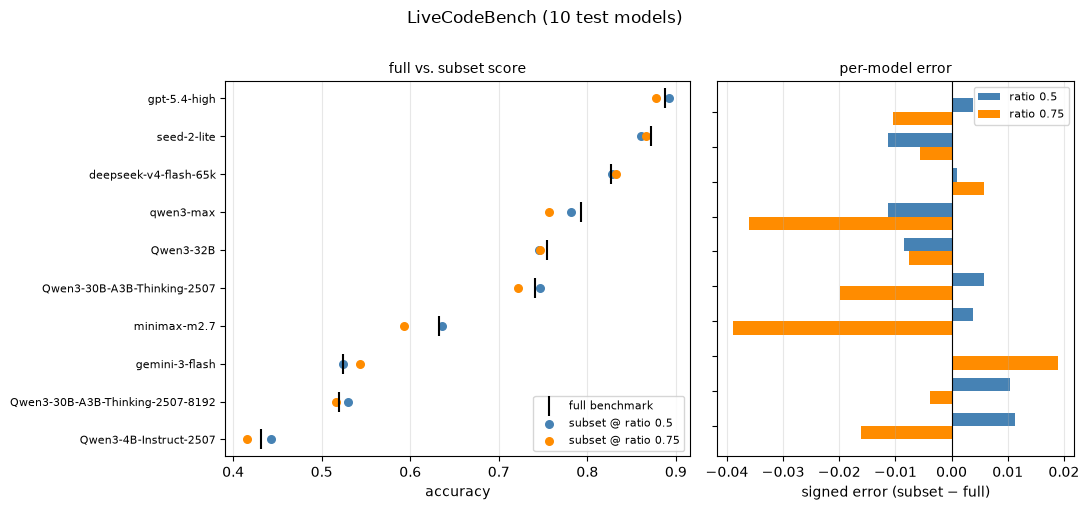

In [12]:
import matplotlib.pyplot as plt

# Per-model view: full-benchmark score vs. weighted-anchor estimate, and the signed error per model.
models = sorted(evals["0p5"]["model_names"], key=lambda m: -evals["0p5"]["full_accuracies"][m])
y = np.arange(len(models))
colors = {"0p5": "steelblue", "0p75": "darkorange"}

fig, (ax_score, ax_err) = plt.subplots(1, 2, figsize=(11, 0.35 * len(models) + 1.5),
                                       gridspec_kw={"width_ratios": [1.3, 1]})

ax_score.scatter([evals["0p5"]["full_accuracies"][m] for m in models], y,
                 color="k", marker="|", s=200, label="full benchmark", zorder=3)
for tag, e in evals.items():
    ax_score.scatter([e["subset_accuracies"][m] for m in models], y,
                     color=colors[tag], s=30, label=f"subset @ ratio {e['ratio']}")
ax_score.set_yticks(y); ax_score.set_yticklabels(models, fontsize=8); ax_score.invert_yaxis()
ax_score.set_xlabel("accuracy"); ax_score.grid(axis="x", alpha=0.3)
ax_score.legend(fontsize=8, loc="lower right"); ax_score.set_title("full vs. subset score", fontsize=10)

h = 0.38
for k, (tag, e) in enumerate(evals.items()):
    ax_err.barh(y + (k - 0.5) * h, [e["per_model_errors"][m] for m in models],
                height=h, color=colors[tag], label=f"ratio {e['ratio']}")
ax_err.axvline(0, color="k", lw=0.8)
ax_err.set_yticks(y); ax_err.set_yticklabels([]); ax_err.invert_yaxis()
ax_err.set_xlabel("signed error (subset − full)"); ax_err.grid(axis="x", alpha=0.3)
ax_err.legend(fontsize=8); ax_err.set_title("per-model error", fontsize=10)

fig.suptitle(f"LiveCodeBench ({len(models)} test models)", y=1.01)
plt.tight_layout()
plt.show()